In [ ]:
"""
This file contains the main guide line for data processing (from raw data to metrics calculation)

Following files are details of some of the method developped here:
Compression_comparison.ipynb
Data_processing_method1.ipynb
Data_processing_method2.ipynb
"""

Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.signal import butter, freqz
from scipy.signal import filtfilt

Loading files and data

In [10]:
#Path of the file to open
path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv" #ADELE
path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv"#ADELE

"""
#Recording of useful data only
data_left_wrist = pd.read_csv(path_left_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
"""
#Recording of useful data only but For pieces of files that were cut with "Cut_files.py"
data_left_wrist = pd.read_csv(path_left_wrist, header = 0, usecols = ['Timestamp','Accelerometer X','Accelerometer Y','Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 0, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])


#Saving data from different sensor
raw_signal = {"left sensor" : [], 
        "right sensor" : []}


#Left wrist
#Convertion of the str data into float
for data_idx in range(len(data_left_wrist)) : 
        #Convertion of commas to dots to allow convertion of str data to float data
        data_left_wrist.loc[data_idx, "Accelerometer X"] = float(data_left_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))
        data_left_wrist.loc[data_idx, "Accelerometer Y"] = float(data_left_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))
        data_left_wrist.loc[data_idx, "Accelerometer Z"] = float(data_left_wrist.loc[data_idx, "Accelerometer Z"].replace(",","."))- 0.981 # -0.981 removes the gravaity factor

        #Saving the magnitude vector for each 0.01s signal (= activity count)
        norm = np.sqrt(data_left_wrist['Accelerometer X'][data_idx]**2 + data_left_wrist['Accelerometer Y'][data_idx]**2 + data_left_wrist['Accelerometer Z'][data_idx]**2)
        #Saving the norm in the database
        raw_signal["left sensor"].append(norm)

#Right wrist
#Convertion of the str data into float
for data_idx in range(len(data_right_wrist)) : 
        #Convertion of commas to dots to allow convertion of str data to float data
        data_right_wrist.loc[data_idx, "Accelerometer X"] = float(data_right_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Y"] = float(data_right_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Z"] = float(data_right_wrist.loc[data_idx, "Accelerometer Z"].replace(",",".")) - 0.981 # -0.981 removes the gravity factor

        #Saving the magnitude vector for each 0.01s signal (= activity count)
        norm = np.sqrt(data_right_wrist['Accelerometer X'][data_idx]**2 + data_right_wrist['Accelerometer Y'][data_idx]**2 + data_right_wrist['Accelerometer Z'][data_idx]**2)
        #Saving the norm in the database
        raw_signal["right sensor"].append(norm)


#List of the differents sensors to separate data from left [0] and right [1] wrist sensor
lst_sensors = [data_left_wrist, data_right_wrist]

Band pass Filter to remove outliers

In [3]:
"""Creation of a band pass butterworth filter with bandwith of 0.13Hz to 2.73Hz and a peak frequency at 0.77Hz.
The design of the filter is based on the description of Peach et al. in the article : "Exploring the ActiLife® filtration algorithm: converting raw acceleration data to counts"."""

# Sampling rate in Hz
fs = 100  

# Frequencies of interest
lowcut = 0.13
highcut = 2.73

# Normalize the frequencies to the Nyquist frequency
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

# Design a Butterworth bandpass filter
order = 4  # Reasonable order for a smooth response
b, a = butter(order, [low, high], btype='band')

# Frequency response visualization
w, h = freqz(b, a, worN=8000)
frequencies = (w / np.pi) * nyq


"""plt.figure(figsize=(6, 4))
plt.plot(frequencies, abs(h), label="Filter Magnitude Response")
plt.axvline(0.13, color='red', linestyle='--', label='0.13 Hz ')
plt.axvline(2.73, color='green', linestyle='--', label='2.73 Hz ')
plt.axvline(0.77, color='purple', linestyle='--', label='0.77 Hz')
plt.title('Band-pass Filter to Simulate ActiLife Filter (100 Hz Sampling Rate)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.grid()
plt.legend()
plt.show()
"""
filtered_signal_df = {"left sensor" : [], 
        "right sensor" : []}

for name_sensor in raw_signal.keys():
    # Signal
    signal_to_filter = raw_signal[name_sensor]

    # Apply the filter
    filtered_signal = filtfilt(b, a, signal_to_filter)

    filtered_signal_df[name_sensor] = np.abs(filtered_signal)
    


Display the filtered signal

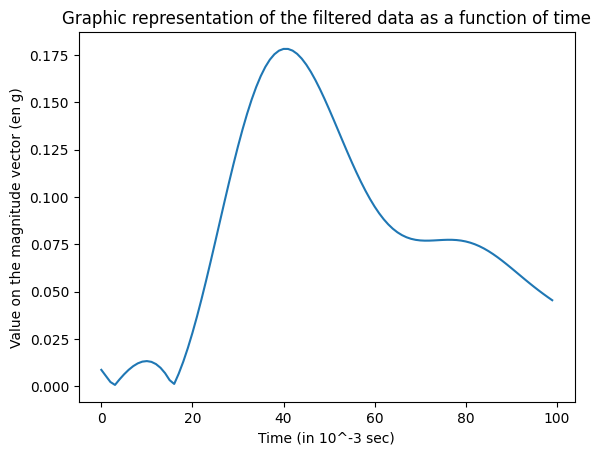

In [4]:
#Display of the filtered signal
x_axis_time = np.arange(100)#len(filtered_signal))
plt.plot(x_axis_time, filtered_signal_df["left sensor"][0:100])
plt.xlabel("Time (in 10^-3 sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()

Absolute value

In [ ]:
#filtered_signal = np.abs(filtered_signal)

Display of both filtered (and absolute) signal and non filtered signals

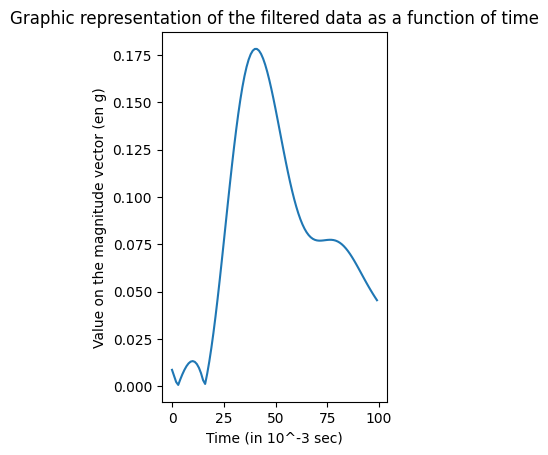

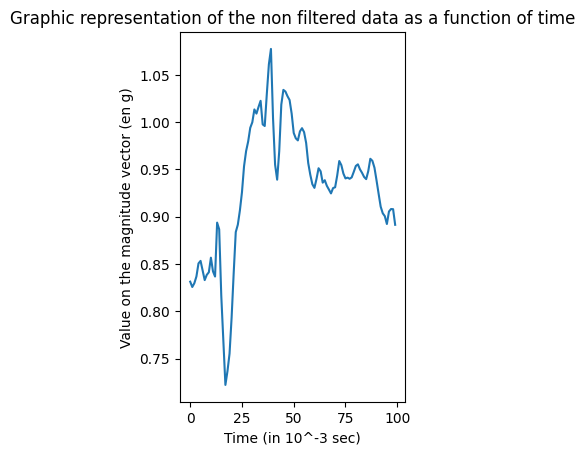

In [5]:
#Display of the filtered signal
x_axis_time = np.arange(100)#np.arange(len(filtered_signal))
plt.subplot(1, 2, 1)
plt.plot(x_axis_time, filtered_signal_df["left sensor"][0:100]) #filtered_signal)
plt.xlabel("Time (in 10^-3 sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()

#Display of the non filtered signal to compare both signals
x_axis_time = np.arange(100)#(len(raw_signal["left sensor"]))
plt.subplot(1, 2, 2)
plt.plot(x_axis_time, raw_signal["left sensor"][0:100])#raw_signal["left sensor"])
plt.xlabel("Time (in 10^-3 sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the non filtered data as a function of time")   
plt.show()

Compression in 1s epochs (instead of 10ms)

1. With Pandas

A. Filtered signal

[8.22869919 4.79438896 2.25979958 1.8331008  1.68960897 1.29857343
 2.28471861 2.7980945  1.17237732 1.42943837]
Mean activity count 1s epoch : 9.721813517177592


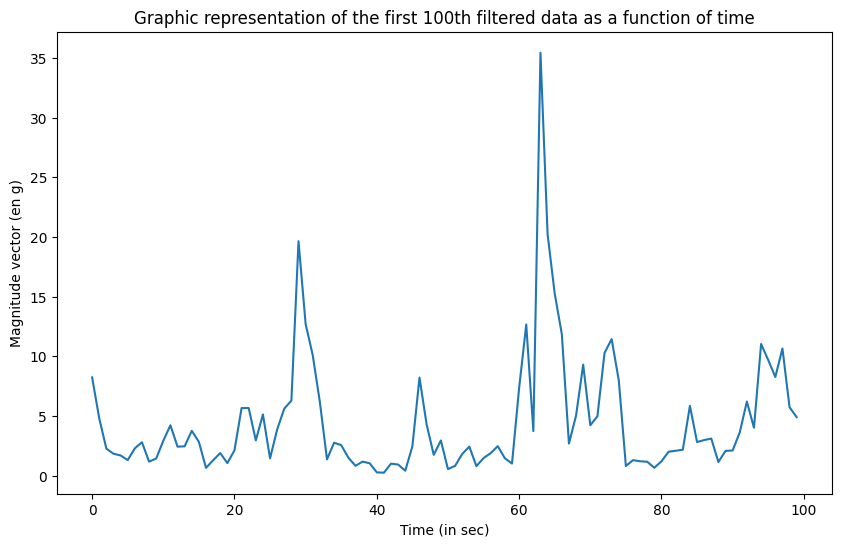

In [6]:
"""Calculation of activity counts and mean activity count"""

#Zero padding to allow the reshaping
signal_len = len(filtered_signal_df["left sensor"])
to_complete = signal_len % 10
if to_complete != 0:
    padding = 10 - to_complete
    padded_signal = np.pad(filtered_signal_df["left sensor"], (0, padding), mode='constant')
else:
    padded_signal_ = filtered_signal_df["left sensor"]

# Reshape in 100 samples epoch (1s epoch)
reshaped_signal = padded_signal.reshape(-1, 100)

# Sum of the magnitude vector for every 1s epoch = activity count
activity_count_1s = np.sum(reshaped_signal, axis=1)
mean_activity_counts =np.mean(activity_count_1s)


print(activity_count_1s[0:10])
print(f"Mean activity count 1s epoch : {mean_activity_counts}")


#Display
x_axis_time = np.arange(100)#(len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s[0:100])#activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Magnitude vector (en g)")
plt.title(f"Graphic representation of the first 100th filtered data as a function of time")   
plt.show()



B. Non filtered signal

[93.01344299 93.55199583 89.52748263 91.11587904 88.65278725 88.56074748
 88.77416222 93.00546878 93.66008566 94.85886097]
Mean activity count 1s epoch : 94.80816268316997


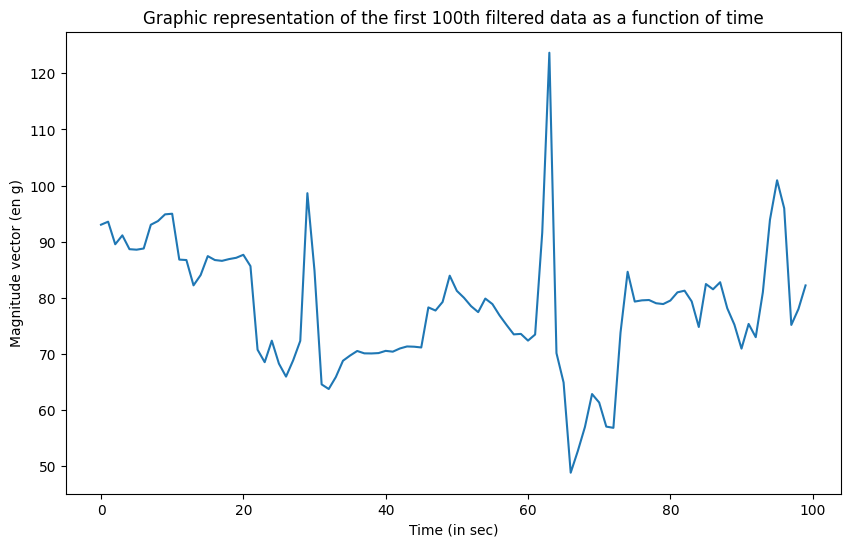

In [7]:
"""Calculation of activity counts and mean activity count"""

#Zero padding to allow the reshaping
signal_len = len(raw_signal["left sensor"])
to_complete = signal_len % 10
if to_complete != 0:
    padding = 10 - to_complete
    padded_signal = np.pad(raw_signal["left sensor"], (0, padding), mode='constant')
else:
    padded_signal_ = raw_signal["left sensor"]

# Reshape in 100 samples epoch (1s epoch)
reshaped_signal = padded_signal.reshape(-1, 100)

# Sum of the magnitude vector for every 1s epoch = activity count
activity_count_1s = np.sum(reshaped_signal, axis=1)
mean_activity_counts =np.mean(activity_count_1s)


print(activity_count_1s[0:10])
print(f"Mean activity count 1s epoch : {mean_activity_counts}")


#Display
x_axis_time = np.arange(100)#(len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s[0:100])#activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Magnitude vector (en g)")
plt.title(f"Graphic representation of the first 100th filtered data as a function of time")   
plt.show()



2. With Numpy : cf comparaison_compression.ipynb

[68.25490501 65.94175688 68.84173231 72.31320638 98.63211459 84.80788296
 64.55814331 63.73206338 65.86880518 68.76974824]
Mean activity count : 94.80816268316997


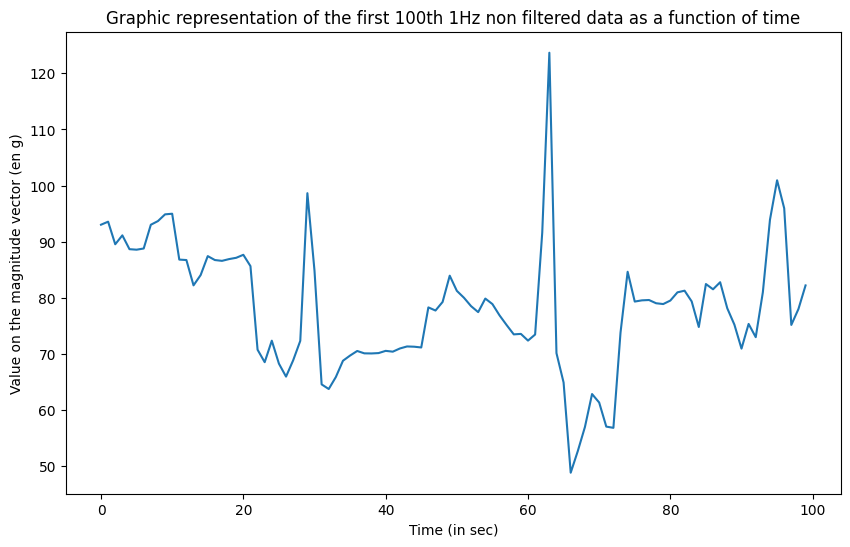

In [8]:
#Zero padding to allow the reshaping
signal_len = len(raw_signal["left sensor"])
to_complete = signal_len % 10
if to_complete != 0:
    padding = 10 - to_complete
    padded_signal = np.pad(raw_signal["left sensor"], (0, padding), mode='constant')
else:
    padded_signal_ = data_left_wrist['Norm']

# Reshape in 100 samples epoch (1s epoch)
reshaped_signal = padded_signal.reshape(-1, 100)

# Sum of the magnitude vector for every 1s epoch = activity count
activity_count_1s = np.sum(reshaped_signal, axis=1)

print(activity_count_1s[25:35])
print(f"Mean activity count : {np.mean(activity_count_1s)}")

#Display
x_axis_time = np.arange(100)#len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s[0:100])#activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the first 100th 1Hz non filtered data as a function of time")   
plt.show()



3. From Scratch : cf compression_comparison.ipynb

METRICS

Active duration : sum of all the sampling where a mouvement is detected (VM > 1) for 1 limb

In [11]:
#Saving the active_durations 
AD_df = {"left sensor": 0,
         "right sensor": 0}

#Saving the active_duration ratios
AD_ratio_df = {"left sensor": 0,
         "right sensor": 0}

"""Metric based on the non filtered data"""

#Active Duration
active_duration = np.sum(np.array(raw_signal["left sensor"]) > 1)

#Active left duration ratio : left_active_duration / (total duration*100)
left_active_duration_ratio = active_duration / ((len(raw_signal["left sensor"])-1)) * 100


print("\n*** Non Filtered Signal ***")
print(f"Active duration : {active_duration} hundredth of a second")
print(f"Active duration ratio : {left_active_duration_ratio} %")


"""Metric based on the filtered data"""

for name_sensor in filtered_signal_df.keys():
    #Active Duration
    active_duration_filtered = np.sum(np.array(filtered_signal_df[name_sensor]) > 1)

    #Active left duration ratio : left_active_duration / (total duration*100)
    active_duration_ratio_filtered = active_duration_filtered / ((len(filtered_signal_df[name_sensor])-1)) * 100

    #Saving the active_durations 
    AD_df[name_sensor] += active_duration_filtered

    #Saving the active_duration ratios
    AD_ratio_df[name_sensor] += active_duration_ratio_filtered
    

print("\n*** Filtered Signal ***")

print(f"Active duration : {AD_df['left sensor']} hundredth of a second")
print(f"Active duration ratio : {AD_ratio_df['left sensor']} %")

print(f"Active duration : {AD_df['right sensor']} hundredth of a second")
print(f"Active duration ratio : {AD_ratio_df['right sensor']} %")



*** Non Filtered Signal ***
Active duration : 229084 hundredth of a second
Active duration ratio : 42.42312008562995 %

*** Filtered Signal ***
Active duration : 839 hundredth of a second
Active duration ratio : 0.15537094581831784 %
Active duration : 3452 hundredth of a second
Active duration ratio : 0.6392616268949145 %


Use ratio : ratio of activity time of affected member to activity time of non affected member (or activity counts instead of activity time)

In [31]:
use_ratio = AD_df["left sensor"] / AD_df["right sensor"] 

print(f"Use ratio : {use_ratio}")

Use ratio : 0.24304750869061414


Magnitude ratio

In [10]:
#Magnitude ratio
magnitude_ratio = np.log(mean_activity_counts[0]/mean_activity_counts[1]) 

print(f"Magnitude ration np : {magnitude_ratio}")

#Magnitude ratio
magn_ratio = math.log(mean_activity_counts[1]/mean_activity_counts[0])

print(f"Magnitude ratio : {magn_ratio}")

IndexError: invalid index to scalar variable.